<a href="https://colab.research.google.com/github/abhi1818sonu-coder/Predictive_Project_2/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Ensure stopwords and punkt are downloaded, if not already
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r"http\S+", "", text)  # remove links
    tokens = word_tokenize(text)  # split words
    tokens = [w for w in tokens if w not in stop_words]  # remove stopwords
    return " ".join(tokens)

# Apply cleaning to the current df
df['clean_text'] = df['text'].apply(clean_text)

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)

LinearSVC()

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      4958
    positive       0.88      0.89      0.89      5042

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Logistic Regression:\n")
print(classification_report(y_test, y_pred2))

Logistic Regression:

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4958
    positive       0.88      0.91      0.89      5042

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



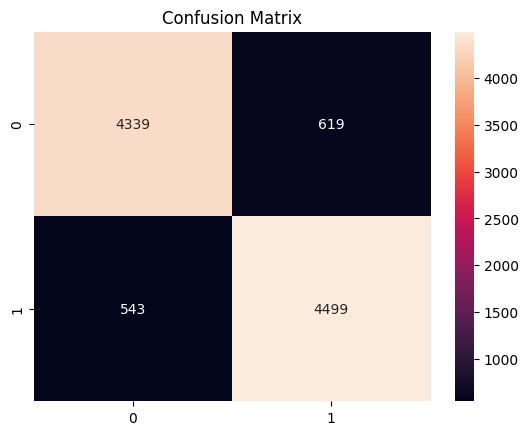

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def convert_label(sentiment):
    if sentiment == "positive":
        return "normal"
    else:
        return "depression"

df['mental_health_status'] = df['label'].apply(convert_label)

df.head()

,text,label,clean_text,mental_health_status
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching 1 oz episode ...,normal
1,A wonderful little production. <br /><br />The...,positive,wonderful little production . < br / > < br / ...,normal
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,normal
3,Basically there's a family where a little boy ...,negative,basically 's family little boy ( jake ) thinks...,depression
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei 's `` love time money '' visuall...,normal


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Convert text into numerical features
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

# Target labels
y = df['mental_health_status']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (40000, 5000)
Testing data shape: (10000, 5000)


Train SVM Model

In [ ]:
from sklearn.svm import LinearSVC

# Create model
model = LinearSVC()

# Train model
model.fit(X_train, y_train)

print("SVM model trained successfully")

SVM model trained successfully


Evaluation

In [ ]:
from sklearn.metrics import classification_report

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  depression       0.89      0.87      0.88      4961
      normal       0.88      0.89      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Confusion Matrix

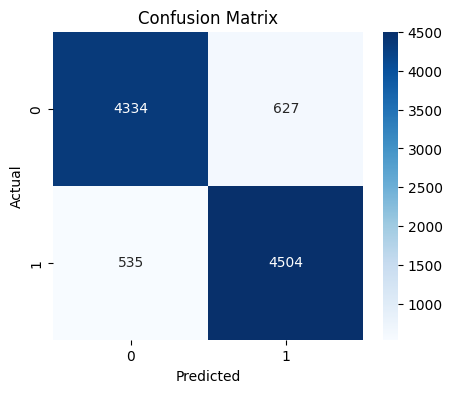

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Logistic Regression (Second Model)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create model
model2 = LogisticRegression()

# Train model
model2.fit(X_train, y_train)

# Predict
y_pred2 = model2.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

  depression       0.90      0.88      0.89      4961
      normal       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



SAVE YOUR MODEL

In [ ]:
import pickle

# Save SVM model
pickle.dump(model, open("mental_health_model.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

print("Model and vectorizer saved successfully")

Model and vectorizer saved successfully


DOWNLOAD THESE FILES

In [ ]:
from google.colab import files

files.download("mental_health_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>